<a href="https://colab.research.google.com/github/samiraghafarigousheh-sys/AIB/blob/main/comparison%20of%20all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from pathlib import Path

REPO = "https://github.com/samiraghafarigousheh-sys/AIB.git"
MAIN_BRANCH = "main"
BASELINE_BRANCH = "claude/pybuildingenergy-baseline-anjro8"

# Private repo? Uncomment and paste a token with `repo` scope:
# TOKEN = "ghp_xxx"
# REPO = f"https://{TOKEN}@github.com/samiraghafarigousheh-sys/AIB.git"

# REPO_ROOT is absolute and fixed for the rest of the notebook. Every later
# cell re-chdirs here explicitly, so cell order / kernel restarts can't drift
# the working directory silently.
REPO_ROOT = Path("/content/AIB").resolve()

%cd /content
!rm -rf AIB
!git clone --quiet --branch $MAIN_BRANCH $REPO AIB
os.chdir(REPO_ROOT)
!git fetch --quiet origin $BASELINE_BRANCH
!git config user.email "colab@example.com"
!git config user.name "Colab"
print("REPO_ROOT:", REPO_ROOT)
print("cwd      :", os.getcwd())
assert (REPO_ROOT / "examples").is_dir(), "clone did not land where expected"
print("✓ Repository cloned on main branch")

/content
REPO_ROOT: /content/AIB
cwd      : /content/AIB
✓ Repository cloned on main branch


In [2]:
import os
os.chdir(REPO_ROOT)

# Uninstall conflicting versions first
!pip uninstall -y numpy scipy pandas requests decorator rich

# Reinstall preferred versions explicitly
# Trying numpy 1.26.4 (for numba) with scipy 1.11.4 (might be compatible with numpy 1.x, but potentially old for Python 3.12)
!pip install -q numpy==1.26.4 scipy==1.11.4 pandas==2.2.2 requests==2.32.4 decorator==4.4.2 rich==13.7.1

# Install pybuildingenergy's requirements (main's requirements.txt matches every branch's — no engine code in it)
!pip install -q -r pybuildingenergy/requirements.txt
print("✓ Dependencies installed")

Found existing installation: numpy 2.3.3
Uninstalling numpy-2.3.3:
  Successfully uninstalled numpy-2.3.3
Found existing installation: scipy 1.16.2
Uninstalling scipy-1.16.2:
  Successfully uninstalled scipy-1.16.2
Found existing installation: pandas 2.3.2
Uninstalling pandas-2.3.2:
  Successfully uninstalled pandas-2.3.2
Found existing installation: requests 2.32.5
Uninstalling requests-2.32.5:
  Successfully uninstalled requests-2.32.5
Found existing installation: decorator 5.2.1
Uninstalling decorator-5.2.1:
  Successfully uninstalled decorator-5.2.1
Found existing installation: rich 14.2.0
Uninstalling rich-14.2.0:
  Successfully uninstalled rich-14.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 r

In [3]:
import os, subprocess, shutil
from pathlib import Path
os.chdir(REPO_ROOT)

baseline_dir = REPO_ROOT / "baseline_engine"
if baseline_dir.exists():
    shutil.rmtree(baseline_dir)
baseline_dir.mkdir()

# git-archive the pybuildingenergy/ tree AS IT IS on the baseline branch, and
# extract it here — this is a separate, untouched copy of the unmodified engine.
# cwd is passed explicitly to subprocess so this does not depend on notebook
# cell-execution order for its working directory.
archive = subprocess.run(
    f"git archive origin/{BASELINE_BRANCH} -- pybuildingenergy | tar -x -C {baseline_dir}",
    shell=True, capture_output=True, text=True, cwd=str(REPO_ROOT),
)
if archive.returncode != 0:
    raise RuntimeError(f"could not fetch baseline engine:\n{archive.stderr}")

baseline_src = (baseline_dir / "pybuildingenergy" / "src").resolve()
assert (baseline_src / "pybuildingenergy" / "source" / "utils.py").is_file(), (
    "baseline engine did not extract where expected"
)
print(f"✓ Baseline engine extracted to: {baseline_src}")

✓ Baseline engine extracted to: /content/AIB/baseline_engine/pybuildingenergy/src


In [4]:
import os, glob
os.chdir(REPO_ROOT)

epw_files = sorted((REPO_ROOT / "weather_cache").glob("*.epw"))
assert epw_files, (
    f"No EPW found in {REPO_ROOT / 'weather_cache'}. Re-run from cell 1 — "
    "the clone likely did not complete."
)
EPW = str(epw_files[0])
print(f"✓ Weather file: {EPW}")

✓ Weather file: /content/AIB/weather_cache/AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw


In [5]:
import os, sys
os.chdir(REPO_ROOT)

examples_dir = REPO_ROOT / "examples"
assert examples_dir.is_dir(), f"{examples_dir} missing — re-run from cell 1"
assert (examples_dir / "weather_melbourne.py").is_file(), (
    f"weather_melbourne.py missing under {examples_dir} — re-run from cell 1"
)

# Absolute paths only. Baseline engine FIRST, so `import pybuildingenergy`
# resolves to the unmodified copy in baseline_engine/, not to main's own
# (modified) pybuildingenergy/src.
for p in (str(baseline_src), str(examples_dir)):
    if p not in sys.path:
        sys.path.insert(0, p)

from weather_melbourne import read_epw_site, site_offset_deg

lat, lon, city = read_epw_site(EPW)
offset = site_offset_deg(lat, lon)

print(f"Weather file  : {EPW}")
print(f"Station       : {city}  (lat {lat}, lon {lon})")
print(f"Offset from central Melbourne: {offset:.2f}°")
print()
print("✓ Weather pinned to single EPW — all runs use identical weather")

Weather file  : /content/AIB/weather_cache/AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw
Station       : Melbourne.RO  (lat -37.8075, lon 144.97)
Offset from central Melbourne: 0.01°

✓ Weather pinned to single EPW — all runs use identical weather


In [6]:
from apt305_building import build_bui
from pybuildingenergy.source.utils import ISO52016
from pybuildingenergy.source.check_input import sanitize_and_validate_BUI
import pybuildingenergy

# Confirm we are really running the baseline copy, not main's own modified one
resolved = Path(pybuildingenergy.__file__).resolve()
assert "baseline_engine" in str(resolved), (
    f"pybuildingenergy resolved to {resolved} — expected it under baseline_engine/. "
    "Restart the runtime and re-run from cell 1."
)
print(f"Engine source : {resolved}")
print("✓ Confirmed: running the UNMODIFIED baseline engine\n")

# Build and validate
bui = build_bui()
building, _ = sanitize_and_validate_BUI(bui, fix=True)

print(f"Building: {building['building']['name']}")
print(f"Floor area: {building['building']['net_floor_area']} m²")
print(f"Adjacent zones: {building['building']['number_adj_zone']}")
print()

# Run engine
result = ISO52016.Temperature_and_Energy_needs_calculation(
    building,
    weather_source="epw",
    path_weather_file=EPW,
)
annual = result[1] if isinstance(result, tuple) else None

if annual is None:
    raise RuntimeError("Failed to get annual results")

import pandas as pd
print("✓ Baseline engine run complete")

Engine source : /content/AIB/baseline_engine/pybuildingenergy/src/pybuildingenergy/__init__.py
✓ Confirmed: running the UNMODIFIED baseline engine

Building: Apt_305_50_Barry_St_Carlton
Floor area: 20.0 m²
Adjacent zones: 5



  8%|▊         | 800/9504 [00:02<00:22, 390.05it/s]

[t=744] T_op0=25.39  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-357.5
[t=745] T_op0=26.45  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-350.6
[t=746] T_op0=26.34  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-473.5
[t=747] T_op0=26.61  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-511.3
[t=748] T_op0=26.99  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-561.1
[t=749] T_op0=27.42  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-618.1


100%|██████████| 9504/9504 [00:20<00:00, 452.92it/s]


SANKEY CHECK  inputs=6779156.0  outputs+storage=6078826.7  residual=700329.3 Wh (10.331%)
✓ Baseline engine run complete


In [7]:
import pandas as pd

# Extract key annual metrics
metrics = {
    "Heating need (kWh)": float(pd.to_numeric(annual["Q_H_annual_kWh"], errors="coerce").iloc[0]),
    "Cooling need (kWh)": float(pd.to_numeric(annual["Q_C_annual_kWh"], errors="coerce").iloc[0]),
    "Solar gains (kWh)": float(pd.to_numeric(annual["Q_solar_gains_kWh"], errors="coerce").iloc[0]),
    "Window transm. loss (kWh)": float(pd.to_numeric(annual["Q_tr_window_loss_kWh"], errors="coerce").iloc[0]),
    "Opaque transm. loss (kWh)": float(pd.to_numeric(annual["Q_tr_opaque_loss_kWh"], errors="coerce").iloc[0]),
    "Total transm. loss (kWh)": float(pd.to_numeric(annual["Q_tr_total_loss_kWh"], errors="coerce").iloc[0]),
}

calib_df = pd.DataFrame([
    (label, f"{value:,.2f}")
    for label, value in metrics.items()
], columns=["Metric", "Value"])

print("="*60)
print("BASELINE CALIBRATION RESULTS — Apt 305")
print("="*60)
display(calib_df)
print()
print(f"Total annual energy (heating + cooling): {metrics['Heating need (kWh)'] + metrics['Cooling need (kWh)']:,.2f} kWh")
print()
print("Expected (from README / compare_branches_apt305.py Baseline column):")
print("  Heating  15.861617 kWh")
print("  Cooling 2027.506478 kWh")

BASELINE CALIBRATION RESULTS — Apt 305


,Metric,Value
0,Heating need (kWh),15.86
1,Cooling need (kWh),"2,027.51"
2,Solar gains (kWh),819.59
3,Window transm. loss (kWh),593.14
4,Opaque transm. loss (kWh),433.55
5,Total transm. loss (kWh),"1,005.17"



Total annual energy (heating + cooling): 2,043.37 kWh

Expected (from README / compare_branches_apt305.py Baseline column):
  Heating  15.861617 kWh
  Cooling 2027.506478 kWh


In [8]:
# Run the engine a second time with identical inputs
result2 = ISO52016.Temperature_and_Energy_needs_calculation(
    building,
    weather_source="epw",
    path_weather_file=EPW,
)
annual2 = result2[1] if isinstance(result2, tuple) else None

# Extract metrics from second run
metrics2 = {
    "Heating need (kWh)": float(pd.to_numeric(annual2["Q_H_annual_kWh"], errors="coerce").iloc[0]),
    "Cooling need (kWh)": float(pd.to_numeric(annual2["Q_C_annual_kWh"], errors="coerce").iloc[0]),
    "Solar gains (kWh)": float(pd.to_numeric(annual2["Q_solar_gains_kWh"], errors="coerce").iloc[0]),
    "Window transm. loss (kWh)": float(pd.to_numeric(annual2["Q_tr_window_loss_kWh"], errors="coerce").iloc[0]),
    "Opaque transm. loss (kWh)": float(pd.to_numeric(annual2["Q_tr_opaque_loss_kWh"], errors="coerce").iloc[0]),
    "Total transm. loss (kWh)": float(pd.to_numeric(annual2["Q_tr_total_loss_kWh"], errors="coerce").iloc[0]),
}

# Compare
TOL = 1e-6  # Tolerance for identical runs
comparison = []
all_match = True

for label in metrics.keys():
    val1 = metrics[label]
    val2 = metrics2[label]
    denom = max(abs(val1), abs(val2), 1e-12)
    rel_diff = abs(val1 - val2) / denom
    match = rel_diff <= TOL
    all_match &= match

    comparison.append({
        "Metric": label,
        "Run 1": f"{val1:,.6f}",
        "Run 2": f"{val2:,.6f}",
        "Rel. diff": f"{rel_diff:.2e}",
        "Status": "✓" if match else "✗"
    })

comp_df = pd.DataFrame(comparison)
print("\n" + "="*80)
print("REPRODUCIBILITY TEST — Same engine, building, weather")
print("="*80)
display(comp_df)
print()
if all_match:
    print("✓ PASS  Both runs give identical results (rel. diff < 1e-6)")
    print("        Baseline calibration is reproducible and reliable.")
else:
    print("✗ FAIL  Results diverged between runs")
    print("        Check for non-determinism or numerical instability.")

  9%|▉         | 845/9504 [00:02<00:23, 370.54it/s]

[t=744] T_op0=25.39  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-357.5
[t=745] T_op0=26.45  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-350.6
[t=746] T_op0=26.34  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-473.5
[t=747] T_op0=26.61  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-511.3
[t=748] T_op0=26.99  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-561.1
[t=749] T_op0=27.42  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449  Phi_lat=-618.1


100%|██████████| 9504/9504 [00:21<00:00, 443.43it/s]


SANKEY CHECK  inputs=6779156.0  outputs+storage=6078826.7  residual=700329.3 Wh (10.331%)

REPRODUCIBILITY TEST — Same engine, building, weather


,Metric,Run 1,Run 2,Rel. diff,Status
0,Heating need (kWh),15.861617,15.861617,0.00e+00,✓
1,Cooling need (kWh),"2,027.506478","2,027.506478",0.00e+00,✓
2,Solar gains (kWh),819.585730,819.585730,0.00e+00,✓
3,Window transm. loss (kWh),593.140118,593.140118,0.00e+00,✓
4,Opaque transm. loss (kWh),433.550030,433.550030,0.00e+00,✓
5,Total transm. loss (kWh),"1,005.170925","1,005.170925",0.00e+00,✓



✓ PASS  Both runs give identical results (rel. diff < 1e-6)
        Baseline calibration is reproducible and reliable.


In [9]:
import json

os.chdir(REPO_ROOT)

# Store calibration reference
calib_ref = {
    "engine": f"ISO52016 baseline (unmodified) — {BASELINE_BRANCH}",
    "building": "Apt 305, 50 Barry St, Carlton",
    "weather": Path(EPW).name,
    "weather_offset_deg": offset,
    "metrics": metrics,
    "timestamp": pd.Timestamp.now().isoformat(),
    "reproducible": all_match,
}

output_dir = REPO_ROOT / "results" / "calibration_baseline"
output_dir.mkdir(parents=True, exist_ok=True)

ref_file = output_dir / "baseline_calibration_reference.json"
ref_file.write_text(json.dumps(calib_ref, indent=2), encoding="utf-8")

print(f"✓ Calibration reference saved: {ref_file}")
print()
print("This reference establishes the GOLDEN STANDARD for this building.")
print("Future runs should always match these values (to numerical precision).")

✓ Calibration reference saved: /content/AIB/results/calibration_baseline/baseline_calibration_reference.json

This reference establishes the GOLDEN STANDARD for this building.
Future runs should always match these values (to numerical precision).


In [10]:
print("\n" + "="*70)
print("CALIBRATION SUMMARY")
print("="*70)
print(f"\nBuilding: Apt 305 — 20 m², Melbourne, one exposed facade")
print(f"Engine:   ISO 52016-1 (unmodified baseline)")
print(f"Weather:  {Path(EPW).name} ({offset:.1f}° from central Melbourne)")
print(f"\nBaseline Results:")
print(f"  Heating:  {metrics['Heating need (kWh)']:>10,.2f} kWh/yr")
print(f"  Cooling:  {metrics['Cooling need (kWh)']:>10,.2f} kWh/yr")
print(f"  Total:    {metrics['Heating need (kWh)'] + metrics['Cooling need (kWh)']:>10,.2f} kWh/yr")
print(f"\nReproducibility: {'✓ PASS' if all_match else '✗ FAIL'}")
print(f"\nThis calibration establishes a fixed reference point for:")
print(f"  • Validating future engine modifications")
print(f"  • Ensuring consistent results on repeated runs")
print(f"  • Comparing against EnergyPlus and other benchmarks")
print("\n" + "="*70)


CALIBRATION SUMMARY

Building: Apt 305 — 20 m², Melbourne, one exposed facade
Engine:   ISO 52016-1 (unmodified baseline)
Weather:  AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw (0.0° from central Melbourne)

Baseline Results:
  Heating:       15.86 kWh/yr
  Cooling:    2,027.51 kWh/yr
  Total:      2,043.37 kWh/yr

Reproducibility: ✓ PASS

This calibration establishes a fixed reference point for:
  • Validating future engine modifications
  • Ensuring consistent results on repeated runs
  • Comparing against EnergyPlus and other benchmarks



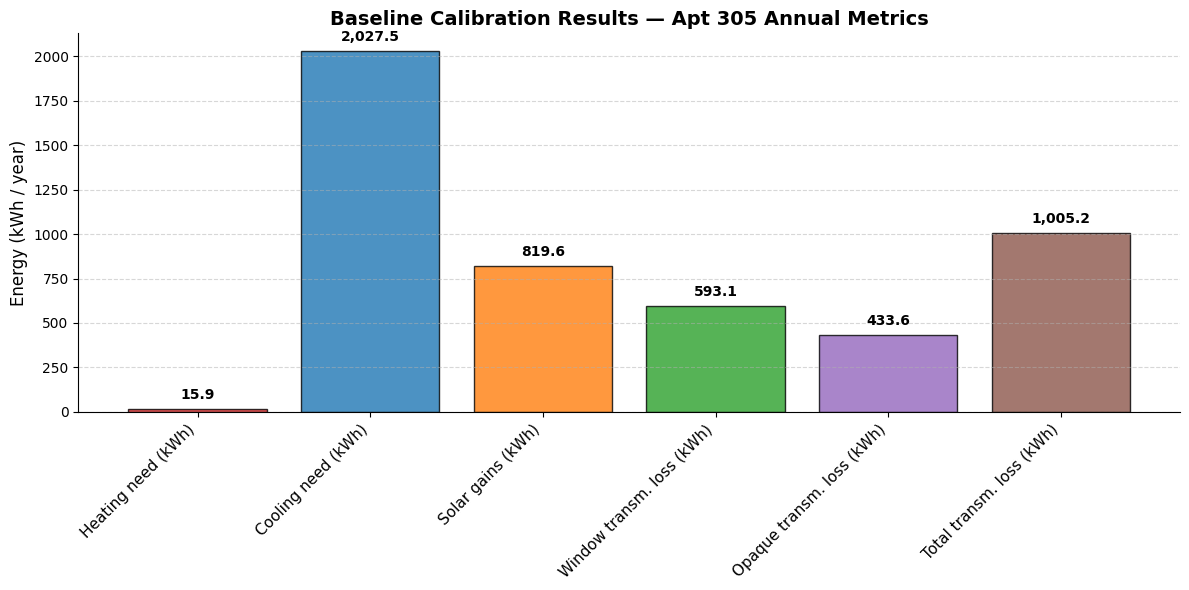

In [11]:
# 10. Visualize Calibration Results
import matplotlib.pyplot as plt

# Extract labels and values from the metrics dictionary generated in Cell 6
labels = list(metrics.keys())
values = list(metrics.values())

# Setup the figure
fig, ax = plt.subplots(figsize=(12, 6))

# Use distinct colors for energy needs (red/blue) vs. heat transfers (yellow/green/etc.)
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

# Create the bar chart
bars = ax.bar(labels, values, color=colors, edgecolor='black', alpha=0.8)

# Add the exact numbers on top of each bar for precision
for bar in bars:
    yval = bar.get_height()
    # Add a slight vertical offset for the text so it doesn't overlap the bar
    offset = max(values) * 0.02
    ax.text(bar.get_x() + bar.get_width()/2, yval + offset,
            f'{yval:,.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting the chart
ax.set_ylabel('Energy (kWh / year)', fontsize=12)
ax.set_title('Baseline Calibration Results — Apt 305 Annual Metrics', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Display the figure
plt.show()